In [1]:
# Repo-root bootstrap: makes source/ importable and data/models paths absolute
# regardless of where the notebook server was started.
import sys
import pathlib

try:
    ROOT = pathlib.Path(__file__).resolve().parents[2]
except NameError:  # __file__ not defined in some environments (e.g. Jupyter console)
    ROOT = pathlib.Path.cwd()
    while not (ROOT / 'source').exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))


In [2]:
import numpy as np
import pandas as pd
from source.moreka import AxonData
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from scipy.stats import poisson
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, LSTM, RepeatVector
from keras.models import Model
import plotly.express as px

from source.sim import generate, moving_average

2026-09-15 15:35:36.263613: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-15 15:35:36.291768: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-15 15:35:36.291795: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-15 15:35:36.292630: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-15 15:35:36.297167: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-15 15:35:36.297476: I tensorflow/core/platform/cpu_feature_guard.cc:1

2026-09-15 15:35:36.996728: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


(6000,)


<Axes: xlabel='time', ylabel='signal'>

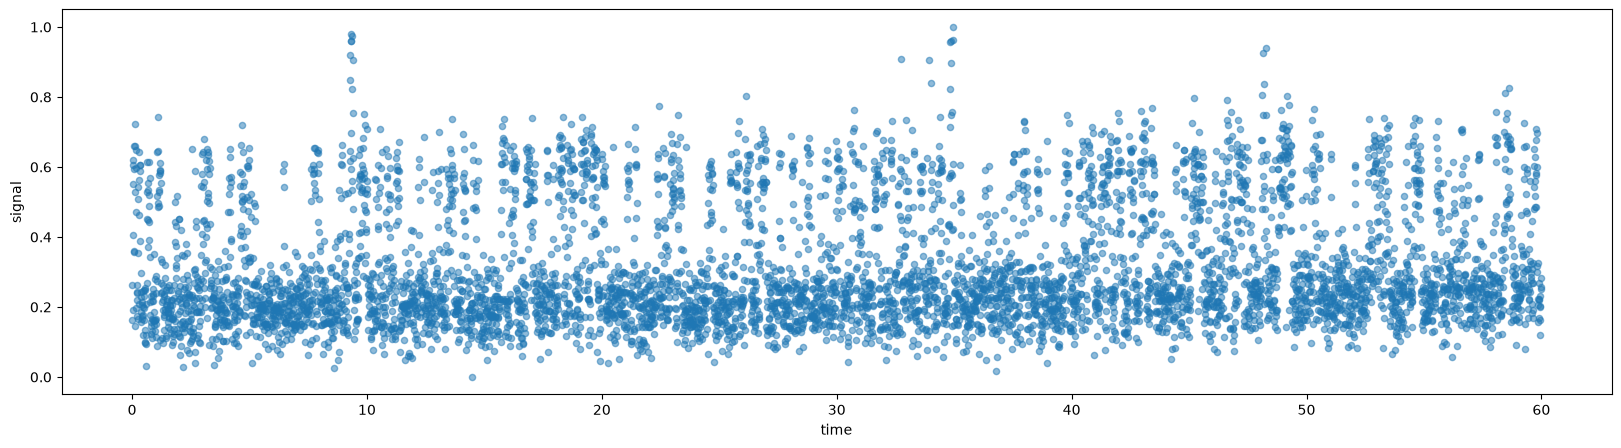

In [3]:
data = AxonData(dirname=str(ROOT / 'data' / 'raw'))
df = data[21].iloc[::100, :]

print(df.signal.shape)
# normalize signal to [0, 1]
df.signal = (df.signal - df.signal.min()) / (df.signal.max() - df.signal.min())
df.plot(x='time', y='signal', figsize=(20, 5), kind='scatter', alpha=0.5)

<Axes: xlabel='time', ylabel='ma'>

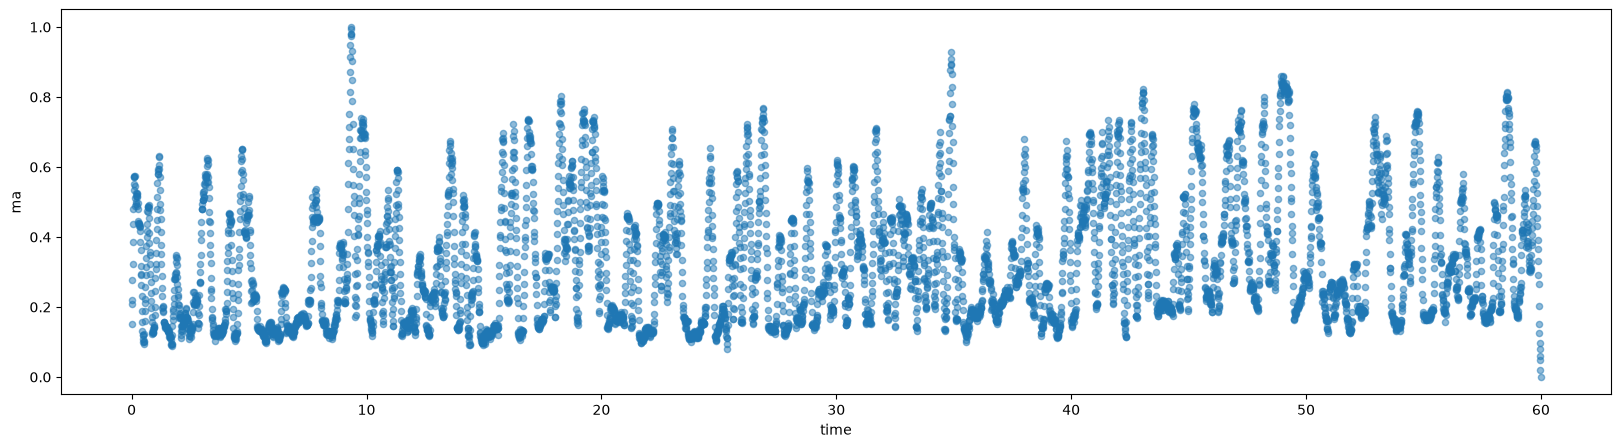

In [4]:
ma = moving_average(df.signal, 20)
# normalize moving average to [0, 1]
ma = (ma - ma.min()) / (ma.max() - ma.min())
df['ma'] = ma
df.plot(x='time', y='ma', figsize=(20, 5), kind='scatter', alpha=0.5)

In [5]:
noised_and_ma = np.concatenate((df.signal, ma), axis=0)
noised_and_ma.reshape(1, 12000)
noised_and_ma.shape

(12000,)

In [6]:
denoiser_path = ROOT / 'code' / '04_ml' / 'models' / 'denoiser.keras'
if denoiser_path.exists():
    model = tf.keras.models.load_model(str(denoiser_path))
else:
    model = None
    print('NOTE: denoiser.keras was never committed; skipping load.')


NOTE: denoiser.keras was never committed; skipping load.


In [7]:
if model is not None:
    denoised = model.predict(noised_and_ma.reshape(1, 12000, 1))
else:
    denoised = None


In [8]:
if denoised is not None:
    plt.figure(figsize=(20, 5))
    plt.scatter(df.time, denoised, alpha=0.1)
    plt.scatter(df.time, df.signal, alpha=0.1, c='r')
    plt.xlim(1, 5)
